In [1]:
# Cell 1 - Imports and Load Clean Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/Reviews_clean.csv')
df['Time'] = pd.to_datetime(df['Time'])

print(f"Data loaded: {df.shape}")
print("Ready for visualization!")

Data loaded: (393914, 13)
Ready for visualization!


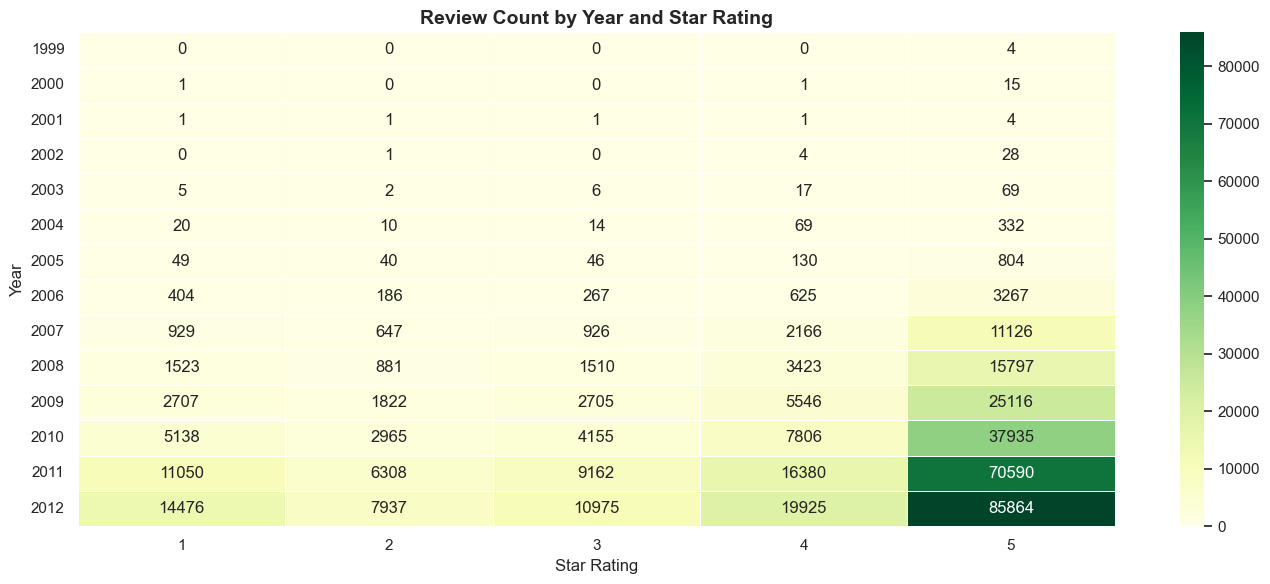

Chart saved!


In [2]:
# Cell 2 - Score Distribution Heatmap by Year
pivot = df.groupby(['Year', 'Score']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGn', linewidths=0.5)
plt.title('Review Count by Year and Star Rating', fontsize=14, fontweight='bold')
plt.xlabel('Star Rating')
plt.ylabel('Year')
plt.tight_layout()
plt.savefig('../images/heatmap_year_score.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

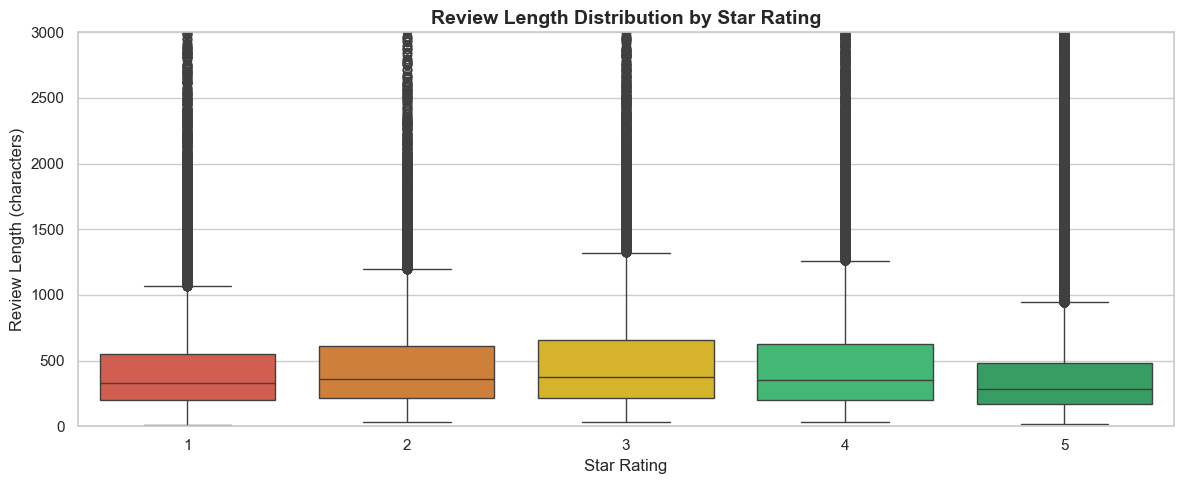

Chart saved!


In [3]:
# Cell 3 - Review Length vs Score
df['review_length'] = df['Text'].str.len()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Score', y='review_length',
            palette=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
plt.ylim(0, 3000)
plt.title('Review Length Distribution by Star Rating', fontsize=14, fontweight='bold')
plt.xlabel('Star Rating')
plt.ylabel('Review Length (characters)')
plt.tight_layout()
plt.savefig('../images/review_length_by_score.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

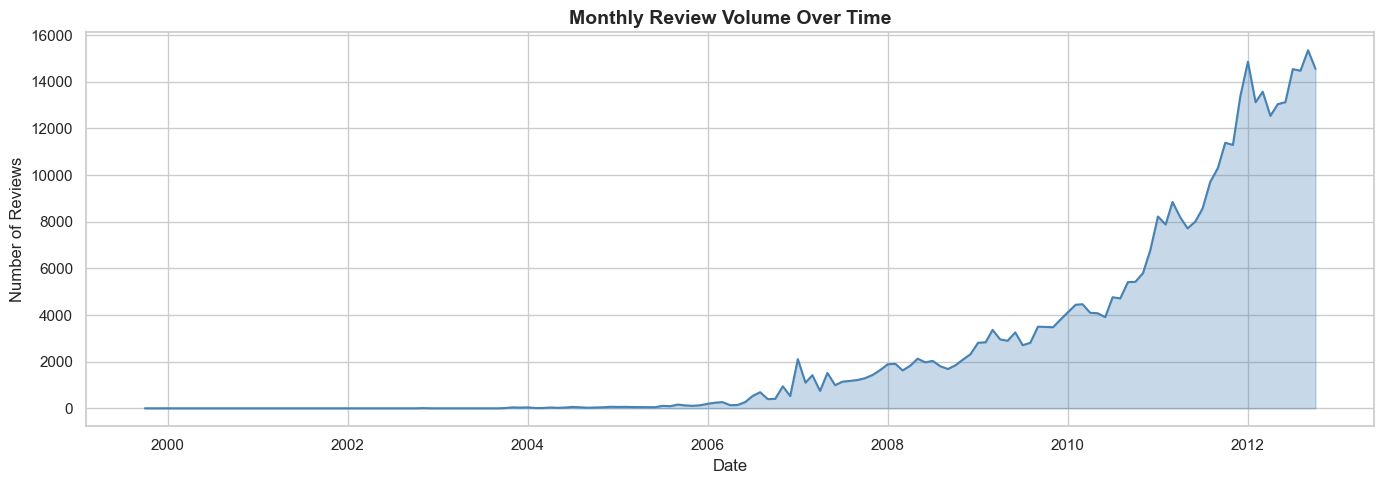

Chart saved!


In [4]:
# Cell 4 - Monthly Review Trends
monthly = df.groupby(['Year', 'Month']).size().reset_index(name='count')
monthly['date'] = pd.to_datetime(monthly[['Year', 'Month']].assign(day=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly['date'], monthly['count'], color='steelblue', linewidth=1.5)
plt.fill_between(monthly['date'], monthly['count'], alpha=0.3, color='steelblue')
plt.title('Monthly Review Volume Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.savefig('../images/monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [5]:
# Cell 5 - Interactive Plotly Chart
yearly = df.groupby(['Year', 'Score']).size().reset_index(name='count')
yearly['Score'] = yearly['Score'].astype(str) + ' ★'

fig = px.bar(yearly, x='Year', y='count', color='Score',
             title='Interactive: Review Counts by Year and Star Rating',
             color_discrete_map={
                 '1 ★': '#e74c3c', '2 ★': '#e67e22',
                 '3 ★': '#f1c40f', '4 ★': '#2ecc71', '5 ★': '#27ae60'},
             labels={'count': 'Number of Reviews', 'Year': 'Year'},
             barmode='stack')

fig.update_layout(legend_title='Star Rating', height=500)
fig.show()
print("Interactive chart rendered!")

Interactive chart rendered!


In [6]:
# Cell 6 - Visualization Summary
print("=" * 45)
print("   VISUALIZATION COMPLETE — CHARTS SAVED")
print("=" * 45)
print("  1. Heatmap — score by year")
print("  2. Boxplot — review length by score")
print("  3. Line chart — monthly review trends")
print("  4. Interactive Plotly — stacked bar chart")
print(f"\n  All charts saved to images/ folder")
print("=" * 45)

   VISUALIZATION COMPLETE — CHARTS SAVED
  1. Heatmap — score by year
  2. Boxplot — review length by score
  3. Line chart — monthly review trends
  4. Interactive Plotly — stacked bar chart

  All charts saved to images/ folder
